# Decision Index 0.2.1: v1 vs v2 vs v3, prompt once vs twice, against Jev and Tev

Four of our models on the same suite, scored by the board's own scorer:

| label | base | LoRA rank | prompt |
|---|---|---|---|
| `scion-v1-plain` | Qwen3 0.6B | 16 | once |
| `scion-v1-repeat` | Qwen3 0.6B | 16 | twice |
| `scion-v2-plain` | Qwen3 4B | 64 | once |
| `scion-v2-repeat` | Qwen3 4B | 64 | twice |
| `scion-v4-repeat` | Qwen3.5 9B | 64 | twice, v3's data (added once `scion_v4.ipynb` has run) |
| `scion-v3-repeat` | Qwen3 4B | 64 | twice, plus the v3 Language/Arts data (added once `scion_v3.ipynb` has run) |

Each model is also reported with a calibration temperature (`+T`) fit on our own dev rows, applied to the cached answers (no new requests). It changes stated confidence, never the chosen option.

Two untrained serverless baselines run too: `zs-emb-8b` (Qwen3 Embedding 8B, picks the option closest to the question) and `zs-rerank-8b` (Qwen3 Reranker 8B, scores each question-option pair). No training, no deployment, temperature fit on our dev rows. The fine-tuned 4B embedder from `scion_embedder_baselines.ipynb` cannot run here: its weights live only inside its training session.

Jev (51.67) and Tev1-4B (26.3) come from the board's published data. The mechanics (engine,
sharded runner, top-5 estimate mode) are explained in `scion_decision_index_single.ipynb`; this notebook
reuses its suite, engine, and any finished run, and adds the paired comparisons.

**Contamination rule, applied to all four identically.** We trained on the train splits of
BANKING77 and CLINC150 (and ARC-Easy, shown on the board but not counted). The board allows that as
"declared overlap", but test questions that also appear verbatim in training count as wrong. Section 5
finds those questions by exact text match against our training file and marks them unanswered, which
the scorer counts as wrong.

## 1. Setup

In [1]:
import hashlib
import json
import os
import re
import subprocess
import sys
import time
from collections import Counter, defaultdict
from math import comb
from pathlib import Path

import dotenv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from fireworks import Fireworks
from tqdm.auto import tqdm

dotenv.load_dotenv(dotenv.find_dotenv(usecwd=True), override=True)
ACCOUNT_ID = os.getenv("FIREWORKS_ACCOUNT_ID", "").replace("accounts/", "", 1)
client = Fireworks()

GO = True
HERE = Path.cwd()
KIT = HERE / "decision-index"
SUITE = HERE / "di_suite-0.2"
RUNS = HERE / "di_runs"
sys.path[:0] = [str(KIT), str(HERE)]
assert (SUITE / "added-rows.jsonl.gz").exists(), "build the suite first (scion_decision_index_single.ipynb, section 2)"

EDITION = "0.2.1"           # the board's current default; same suite files as 0.2, new scoring
MAX_LOGPROBS = 5            # non-superuser cap; the model's pick is exact, tail probabilities estimated
SHARDS_PER_MODEL = 12       # two models share each deployment -> 24 in flight per deployment
GPU_USD_PER_HOUR = 6.00     # placeholder; set to your rate

_4B_EXTRA = dict(precision="BF16", disable_speculative_decoding=True)
DEPLOYMENTS = {
    "0p6b": dict(id="jev-di-0p6b", base="accounts/fireworks/models/qwen3-0p6b", extra={}),
    "4b": dict(id="jev-di-4b", base="accounts/fireworks/models/qwen3-4b", extra=_4B_EXTRA),
    "9b": dict(id="jev-di-9b", base="accounts/fireworks/models/qwen3p5-9b", extra={}),
}
MODELS = [
    dict(label="scion-v1-plain", lora="jev-0p6b-plain-5f25c2", repeat=False, dep="0p6b", train="runs/5f25c2/train_plain.jsonl"),
    dict(label="scion-v1-repeat", lora="jev-0p6b-repeat-5f25c2", repeat=True, dep="0p6b", train="runs/5f25c2/train_plain.jsonl"),
    dict(label="scion-v2-plain", lora="jev-4b-plain-511422", repeat=False, dep="4b", train="runs/v2-511422/train_plain.jsonl"),
    dict(label="scion-v2-repeat", lora="jev-4b-repeat-511422", repeat=True, dep="4b", train="runs/v2-511422/train_plain.jsonl"),
]
_v3 = sorted(Path("runs").glob("v3-*/calibration.json"), key=lambda p: p.stat().st_mtime)
if _v3:
    _cal = json.loads(_v3[-1].read_text())
    MODELS.append(dict(label="scion-v3-repeat", lora=_cal["model"].split("/")[-1], repeat=True, dep="4b",
                       train=str(_v3[-1].parent / "train_repeat.jsonl")))
_v4 = sorted(Path("runs").glob("v4-*/calibration.json"), key=lambda p: p.stat().st_mtime)
if _v4:
    _cal4 = json.loads(_v4[-1].read_text())
    MODELS.append(dict(label="scion-v4-repeat", lora=_cal4["model"].split("/")[-1], repeat=True, dep="9b",
                       train=str(_v4[-1].parent / "train_repeat.jsonl"), tokenizer=_cal4.get("tokenizer", "Qwen/Qwen3.5-9B")))
    if _cal4.get("model_plain"):
        MODELS.append(dict(label="scion-v4-plain", lora=_cal4["model_plain"].split("/")[-1], repeat=False, dep="9b",
                           train=str(_v4[-1].parent / "train_plain.jsonl"), tokenizer=_cal4.get("tokenizer", "Qwen/Qwen3.5-9B")))
# Zero-shot serverless baselines: no training, no deployment. Temperature fit on our dev rows from the
# embedder notebook's cached scores (same rows as v1/v2 dev), applied inside the engine.
import calibration as JC

_dev_gold = {r["idx"]: (r["gold"], r["split"]) for r in map(json.loads, open("runs/308a44/eval_sft_plain.jsonl"))}


def _serverless_temperature(scores_file):
    rows = []
    for i, sc in enumerate(json.load(open(scores_file))):
        g, split = _dev_gold[i]
        if split == "dev":
            z = np.array(sc); pr = np.exp(z - z.max()); rows.append({"probs": (pr / pr.sum()).tolist(), "gold": g})
    return JC.fit_temperature(rows, lo=0.005, hi=20)["temperature"]


for _label, _engine, _model, _scores in (
        ("zs-emb-8b", "embed_engine:EmbedderEngine", "fireworks/qwen3-embedding-8b", "runs/embedder/scores_zs-emb-8b.json"),
        ("zs-rerank-8b", "embed_engine:RerankerEngine", "fireworks/qwen3-reranker-8b", "runs/embedder/scores_zs-rerank-8b.json")):
    if Path(_scores).exists():
        MODELS.append(dict(label=_label, serverless=True, engine=_engine, dep=None, train=None, repeat=False,
                           engine_opts={"model": _model, "temperature": _serverless_temperature(_scores)}))
# Where each model's calibration temperature is fit: its own training notebook's dev rows.
CAL_SOURCE = {"scion-v1-plain": "runs/308a44/eval_sft_plain.jsonl", "scion-v1-repeat": "runs/308a44/eval_sft_repeat.jsonl",
              "scion-v2-plain": "runs/v2-511422/eval_sft_plain.jsonl", "scion-v2-repeat": "runs/v2-511422/eval_sft_repeat.jsonl",
              "scion-v3-repeat": str(_v3[-1]) if _v3 else None, "scion-v4-repeat": str(_v4[-1]) if _v4 else None,
              "scion-v4-plain": str(_v4[-1].parent / "eval_sft_plain.jsonl") if _v4 else None}
for m in MODELS:
    m["dir"] = RUNS / m["label"]
    if m.get("serverless"):
        m["state"] = "READY"
        print(f"{m['label']:16s} {m['engine_opts']['model']:26s} serverless, T={m['engine_opts']['temperature']:.3f}")
        continue
    m["lora_full"] = f"accounts/{ACCOUNT_ID}/models/{m['lora']}"
    m["state"] = client.models.get(m["lora"]).state
    print(f"{m['label']:16s} {m['lora']:26s} {m['state']}")

/Users/sinan/cookbook/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scion-v1-plain    jev-0p6b-plain-5f25c2      READY
scion-v1-repeat   jev-0p6b-repeat-5f25c2     READY
scion-v2-plain    jev-4b-plain-511422        READY
scion-v2-repeat   jev-4b-repeat-511422       READY
scion-v3-repeat   jev-4b-v3-repeat-34b0e4    READY
scion-v4-repeat   jev-9b-v4-repeat-15a8ac    READY
scion-v4-plain    jev-9b-v4-plain-15a8ac     READY
zs-emb-8b        fireworks/qwen3-embedding-8b serverless, T=0.041
zs-rerank-8b     fireworks/qwen3-reranker-8b serverless, T=1.090


## 2. Load the suite

Also records each scoreable question's gold answer, used for calibration and the paired tests.

In [2]:
from decision_index.suite.io import Suite, read_jsonl

suite = Suite(SUITE, "0.2")
excluded = suite.excluded()
META = {}          # run_id -> (catalog_id, dataset, expected)
n_questions = 0
for path in suite.row_paths:
    for r in read_jsonl(path):
        e = r["_evaluation"]
        if e["run_id"] in excluded or not suite.in_edition(e):
            continue
        META[e["run_id"]] = (e["catalog_id"], e.get("dataset"), r.get("expected"), r["state"], r["questions"])
        n_questions += len(r["questions"])
print(f"scoreable requests {len(META):,}; questions {n_questions:,}")

scoreable requests 151,034; questions 344,403


## 3. Deployments

One deployment per base model, each serving both of its LoRAs. Created here without an admin (top-5
mode). A model whose LoRA is not `READY` yet (v2 while it uploads) is skipped for now; re-run
from this section once it is ready, and finished runs are never repeated.

In [3]:
def finished(m):
    return (m["dir"] / "index.json").exists()


todo = [m for m in MODELS if not finished(m) and m["state"] == "READY"]
waiting = [m["label"] for m in MODELS if not finished(m) and m["state"] != "READY"]
print("already scored:", [m["label"] for m in MODELS if finished(m)])
print("to run now:", [m["label"] for m in todo])
print("waiting for LoRA upload:", waiting or "none")

hdr = {"Authorization": f"Bearer {os.environ['FIREWORKS_API_KEY']}", "Content-Type": "application/json"}
for key in sorted({m["dep"] for m in todo if m["dep"]}):
    d = DEPLOYMENTS[key]
    spec = dict(base_model=d["base"], deployment_id=d["id"], accelerator_type="NVIDIA_H100_80GB", enable_addons=True,
                min_replica_count=1, max_replica_count=1, extra_query={"acceptShapelessRisk": "true"}, **d["extra"])
    client.deployments.create(**spec, validate_only=True)
    if GO:
        try:
            client.deployments.create(**spec)
            print("created", d["id"])
        except Exception as e:  # noqa: BLE001
            print(f"{d['id']}: {str(e)[:120]} (fine if it already exists)")
            try:
                client.deployments.update(d["id"], base_model=d["base"], min_replica_count=1, max_replica_count=1)
                client.deployments.scale(d["id"], replica_count=1)
            except Exception as e2:  # noqa: BLE001
                print("  scale-up:", str(e2)[:120])
    for i in range(240):
        st = client.deployments.get(d["id"]).state
        print(f"[{d['id']}] {i + 1:03d} state={st}", flush=True)
        if st == "READY":
            break
        if st == "FAILED":
            raise RuntimeError(f"{d['id']} FAILED")
        time.sleep(15)
    d["name"] = f"accounts/{ACCOUNT_ID}/deployments/{d['id']}"

for m in todo:
    if m.get("serverless"):
        continue
    d = DEPLOYMENTS[m["dep"]]
    m["model_on_dep"] = f"{m['lora_full']}#{d['name']}"
    try:
        client.lora.load(model=m["lora_full"], deployment=d["name"])
    except Exception as e:  # noqa: BLE001
        print(f"lora.load {m['label']}: {str(e)[:100]} (fine if already loaded)")
    for i in range(60):
        r = requests.post("https://api.fireworks.ai/inference/v1/chat/completions", headers=hdr, timeout=120, json={
            "model": m["model_on_dep"], "messages": [{"role": "user", "content": "Say A."}], "temperature": 0,
            "max_tokens": 10_000, "logprobs": True, "top_logprobs": MAX_LOGPROBS, "reasoning_effort": "none"})
        if r.ok:
            print(f"{m['label']}: serving")
            break
        print(f"[{m['label']}] {i + 1:02d} not ready: {r.status_code} {r.text[:80]}", flush=True)
        time.sleep(20)
    else:
        raise TimeoutError(f"{m['label']} never became servable")

already scored: ['scion-v1-plain', 'scion-v1-repeat', 'scion-v2-plain', 'scion-v2-repeat', 'scion-v3-repeat', 'scion-v4-repeat', 'scion-v4-plain', 'zs-emb-8b', 'zs-rerank-8b']
to run now: []
waiting for LoRA upload: none


## 4. Run

Each model gets `SHARDS_PER_MODEL` runner processes, all models at once. Every shard appends to its
own `results.jsonl`, so re-running this cell resumes. Progress is also visible on disk
(`ls -lt di_runs/*/shard-*`).

In [4]:
if todo:
    per_call_s = 0.35
    hours = {m["label"]: n_questions * per_call_s * (2 if m["repeat"] else 1) * {"0p6b": 1, "4b": 2.5, "9b": 4, None: 1}[m["dep"]]
             / SHARDS_PER_MODEL / 3600 for m in todo}
    dep_hours = sum(max(h for l, h in hours.items() if next(x for x in todo if x["label"] == l)["dep"] == k)
                    for k in {m["dep"] for m in todo if m["dep"]})
    print("rough wall-clock per model (h):", {k: round(v, 1) for k, v in hours.items()})
    print(f"rough deployment time {dep_hours:.1f}-{2 * dep_hours:.1f} GPU-h -> ~${dep_hours * GPU_USD_PER_HOUR:.0f}-"
          f"{2 * dep_hours * GPU_USD_PER_HOUR:.0f}")

env = {**os.environ, "PYTHONPATH": os.pathsep.join([str(HERE), str(KIT)]), "HF_HUB_DISABLE_XET": "1"}
procs = defaultdict(list)
if GO:
    for m in todo:
        if m.get("serverless"):
            opts, engine, n_shards = json.dumps(m["engine_opts"]), m["engine"], 8   # shared serverless endpoint
        else:
            opts = json.dumps({"model": m["model_on_dep"], "repeat": m["repeat"], "max_logprobs": MAX_LOGPROBS,
                               "tokenizer": m.get("tokenizer", "Qwen/Qwen3-0.6B")})
            engine, n_shards = "scion_engine:ScionEngine", SHARDS_PER_MODEL
        for s in range(n_shards):
            out = m["dir"] / f"shard-{s:02d}"
            out.mkdir(parents=True, exist_ok=True)
            procs[m["label"]].append(subprocess.Popen(
                [sys.executable, str(HERE / "di_shard.py"), "--suite-dir", str(SUITE), "--shard", str(s),
                 "--n-shards", str(n_shards), "--out", str(out), "--engine-options", opts, "--engine", engine],
                stdout=open(out / "runner.log", "a"), stderr=subprocess.STDOUT, env=env))


def counts(m):
    c = Counter()
    for f in m["dir"].glob("shard-*/results.jsonl"):
        for line in open(f, encoding="utf-8"):
            if line.endswith("\n"):
                c[json.loads(line)["status"]] += 1
    return c


bars = {m["label"]: tqdm(total=len(META), desc=m["label"]) for m in todo}
while any(p.poll() is None for ps in procs.values() for p in ps):
    for m in todo:
        c = counts(m)
        b = bars[m["label"]]
        b.n = sum(c.values()); b.set_postfix(ok=c["ok"], unsup=c["unsupported"], err=c["error"]); b.refresh()
    time.sleep(30)
for m in todo:
    c = counts(m); bars[m["label"]].n = sum(c.values()); bars[m["label"]].refresh(); bars[m["label"]].close()
    bad = [s for s, p in enumerate(procs[m["label"]]) if p.returncode]
    print(m["label"], dict(c), "| failed shards:", bad or "none")

## 5. Contamination rule, merge, and score

A suite question counts as wrong for our models if its entire question text (every line of the state
and instructions, 4+ words) appears verbatim in our training data, after lowercasing and stripping
punctuation. A shared passage alone does not count: ANLI reuses some RTE premises with new
hypotheses, and SGD shares stock replies such as "yes that is right". Those requests are marked
`unsupported` before scoring, which the board's scorer counts as wrong. The same set applies to all
four models because v1 and v2 trained on identical rows.

In [5]:
PREFIX = re.compile(r"^[A-Za-z ]{2,30}:\s*")


def norm(s):
    return " ".join(re.sub(r"[^a-z0-9 ]", " ", str(s).lower()).split())


def strings(o):
    if isinstance(o, str):
        yield o
    elif isinstance(o, dict):
        for v in o.values():
            yield from strings(v)
    elif isinstance(o, list):
        for v in o:
            yield from strings(v)


def train_bodies(path):
    out = set()
    for line in open(HERE / path, encoding="utf-8"):
        user = json.loads(line)["messages"][1]["content"].split("\n\nLet me repeat that:\n\n")[0]
        for field in str(json.loads(user)["state"]).split("\n"):
            b = norm(PREFIX.sub("", field.strip()))
            if len(b.split()) >= 4:
                out.add(b)
    return out


def question_lines(state, qs):
    # Question text only (state + instructions, per line). Option descriptions are excluded because
    # label names like "do you have pets" collide with short training utterances.
    raw = list(strings(state)) + [q.get("instructions", "") for q in qs.values()]
    return {t for t in (norm(PREFIX.sub("", l.strip())) for x in raw for l in str(x).split("\n")) if len(t.split()) >= 4}


LINES = {rid: question_lines(state, qs) for rid, (_, _, _, state, qs) in META.items()}
_freq = Counter(t for ts in LINES.values() for t in ts)
BOILERPLATE = {t for t, n in _freq.items() if n > 50}   # fixed instructions shared across a benchmark

CONTAMINATED = {}
for train_path in sorted({m["train"] for m in MODELS if m["train"]}):
    bodies = train_bodies(train_path)
    hits = set()
    for rid in META:
        texts = LINES[rid] - BOILERPLATE
        # The whole question must be in training, not just a shared passage (ANLI reuses RTE premises
        # with new hypotheses; SGD shares stock replies like "yes that is right").
        if texts and texts <= bodies:
            hits.add(rid)
    CONTAMINATED[train_path] = hits
    print(f"{train_path}: {len(hits)} suite requests overlap verbatim;",
          dict(Counter(META[r][1] for r in hits)))


def merge_and_score(m):
    seen = {}
    for f in sorted(m["dir"].glob("shard-*/results.jsonl")):
        for line in open(f, encoding="utf-8"):
            if line.endswith("\n"):
                r = json.loads(line)
                if r["run_id"] not in seen or seen[r["run_id"]]["status"] == "error":
                    seen[r["run_id"]] = r
    if not seen and (m["dir"] / "results.jsonl").exists():   # a run scored by scion_decision_index_single.ipynb
        seen = {r["run_id"]: r for r in map(json.loads, open(m["dir"] / "results.jsonl", encoding="utf-8"))}
    for rid in CONTAMINATED.get(m["train"], set()):
        if rid in seen and seen[rid]["status"] == "ok":
            seen[rid] = {k: v for k, v in seen[rid].items() if k not in ("response", "raw_output")}
            seen[rid].update(status="unsupported", error="trained on this test item (exact overlap)")
    merged = m["dir"] / "results.scored.jsonl"
    with open(merged, "w", encoding="utf-8") as f:
        for r in seen.values():
            f.write(json.dumps(r) + "\n")
    subprocess.run([sys.executable, "-m", "decision_index", "score", "--results", str(merged), "--suite-dir", str(SUITE), "--edition", EDITION,
                    "--engine", m["label"], "--out", str(m["dir"])], check=True, capture_output=True,
                   env={**os.environ, "PYTHONPATH": str(KIT)})
    m["results"] = seen
    m["index"] = json.loads((m["dir"] / "index.json").read_text())
    print(f"{m['label']:16s} index {m['index']['index']:6.2f}  raw {m['index']['raw_index']:6.2f}  "
          f"requests {len(seen):,}/{len(META):,}  {dict(Counter(r['status'] for r in seen.values()))}")


READY_MODELS = [m for m in MODELS if any(m["dir"].glob("shard-*/results.jsonl")) or (m["dir"] / "results.jsonl").exists()]
for m in READY_MODELS:
    merge_and_score(m)

runs/5f25c2/train_plain.jsonl: 20 suite requests overlap verbatim; {'ARC-Challenge': 2, 'BANKING77': 8, 'CLINC150+OOS': 3, 'ANLI': 1, 'ARC-Easy': 6}
runs/v2-511422/train_plain.jsonl: 20 suite requests overlap verbatim; {'ARC-Challenge': 2, 'BANKING77': 8, 'CLINC150+OOS': 3, 'ANLI': 1, 'ARC-Easy': 6}
runs/v3-34b0e4/train_repeat.jsonl: 1 suite requests overlap verbatim; {'CLINC150+OOS': 1}
runs/v4-15a8ac/train_plain.jsonl: 1 suite requests overlap verbatim; {'CLINC150+OOS': 1}
runs/v4-15a8ac/train_repeat.jsonl: 1 suite requests overlap verbatim; {'CLINC150+OOS': 1}
scion-v1-plain    index  12.59  raw  33.36  requests 151,034/151,034  {'ok': 150991, 'error': 23, 'unsupported': 20}
scion-v1-repeat   index  14.11  raw  34.84  requests 151,034/151,034  {'ok': 151010, 'unsupported': 22, 'error': 2}
scion-v2-plain    index  26.75  raw  44.05  requests 151,034/151,034  {'ok': 150213, 'error': 801, 'unsupported': 20}
scion-v2-repeat   index  28.08  raw  44.48  requests 151,034/151,034  {'ok': 15

### Calibration temperature (`+T`)

Each model's stated confidence runs ahead of its accuracy. A single temperature T, fit on that model's
own dev rows (never the Decision Index), softens every probability alike. The chosen option never
changes, so accuracy, F1 and most of the index are untouched; it moves the probability-scored parts
(ForecastBench's Brier score, the ranking benchmarks) and calibration. `+T` rows below reuse the cached
answers, no new requests.

In [6]:
import calibration as JC

for m in list(READY_MODELS):
    src = CAL_SOURCE.get(m["label"])
    if not src:
        continue
    fit = json.loads(Path(src).read_text()) if src.endswith("calibration.json") else JC.fit_from_eval_file(src)
    t_dir = RUNS / f"{m['label']}-T"
    t_dir.mkdir(exist_ok=True)
    JC.save({**fit, "fit_on": src}, t_dir / "calibration.json")
    JC.rescale_results(m["dir"] / "results.scored.jsonl", t_dir / "results.scored.jsonl", fit["temperature"])
    subprocess.run([sys.executable, "-m", "decision_index", "score", "--results", str(t_dir / "results.scored.jsonl"),
                    "--suite-dir", str(SUITE), "--edition", EDITION, "--engine", f"{m['label']}-T", "--out", str(t_dir)], check=True,
                   capture_output=True, env={**os.environ, "PYTHONPATH": str(KIT)})
    t_model = {**m, "label": m["label"] + " +T", "dir": t_dir, "index": json.loads((t_dir / "index.json").read_text()),
               "results": {r["run_id"]: r for r in map(json.loads, open(t_dir / "results.scored.jsonl", encoding="utf-8"))}}
    READY_MODELS.append(t_model)
    print(f"{m['label']:16s} T={fit['temperature']:.2f}  index {m['index']['index']:6.2f} -> {t_model['index']['index']:6.2f}  "
          f"ForecastBench raw {m['index']['benchmarks']['48']['raw']:.3f} -> {t_model['index']['benchmarks']['48']['raw']:.3f}")
print("Index moves little because most benchmarks score only the chosen option; calibration (section below) is where +T shows.")

scion-v1-plain    T=1.50  index  12.59 ->  12.58  ForecastBench raw 0.000 -> 0.000
scion-v1-repeat   T=1.44  index  14.11 ->  14.11  ForecastBench raw 0.000 -> 0.000
scion-v2-plain    T=1.66  index  26.75 ->  26.78  ForecastBench raw 0.000 -> 0.019
scion-v2-repeat   T=1.55  index  28.08 ->  28.13  ForecastBench raw 0.000 -> 0.030
scion-v3-repeat   T=1.92  index  30.87 ->  30.95  ForecastBench raw 0.138 -> 0.182
scion-v4-repeat   T=1.73  index  45.81 ->  45.86  ForecastBench raw 0.000 -> 0.028
scion-v4-plain    T=1.64  index  41.25 ->  41.31  ForecastBench raw 0.169 -> 0.206
Index moves little because most benchmarks score only the chosen option; calibration (section below) is where +T shows.


## 6. Results

,index,knowledge,language,retrieval,tools,arts
model,,,,,,
Jev (jev-1.13.0),57.91,0.514,0.620,0.554,0.751,0.377
Tev1-4B (Together),29.24,0.235,0.392,0.155,0.418,0.229
scion-v1-plain,12.59,0.053,0.140,0.079,0.293,0.066
scion-v1-repeat,14.11,0.067,0.149,0.123,0.285,0.085
scion-v2-plain,26.75,0.165,0.325,0.231,0.449,0.124
scion-v2-repeat,28.08,0.206,0.318,0.240,0.451,0.150
scion-v3-repeat,30.87,0.205,0.341,0.260,0.515,0.214
scion-v4-repeat,45.81,0.316,0.514,0.479,0.651,0.288
scion-v4-plain,41.25,0.291,0.472,0.430,0.550,0.284


index: 0 = random guessing, 100 = perfect. Area columns: 0-1 chance-corrected skill.


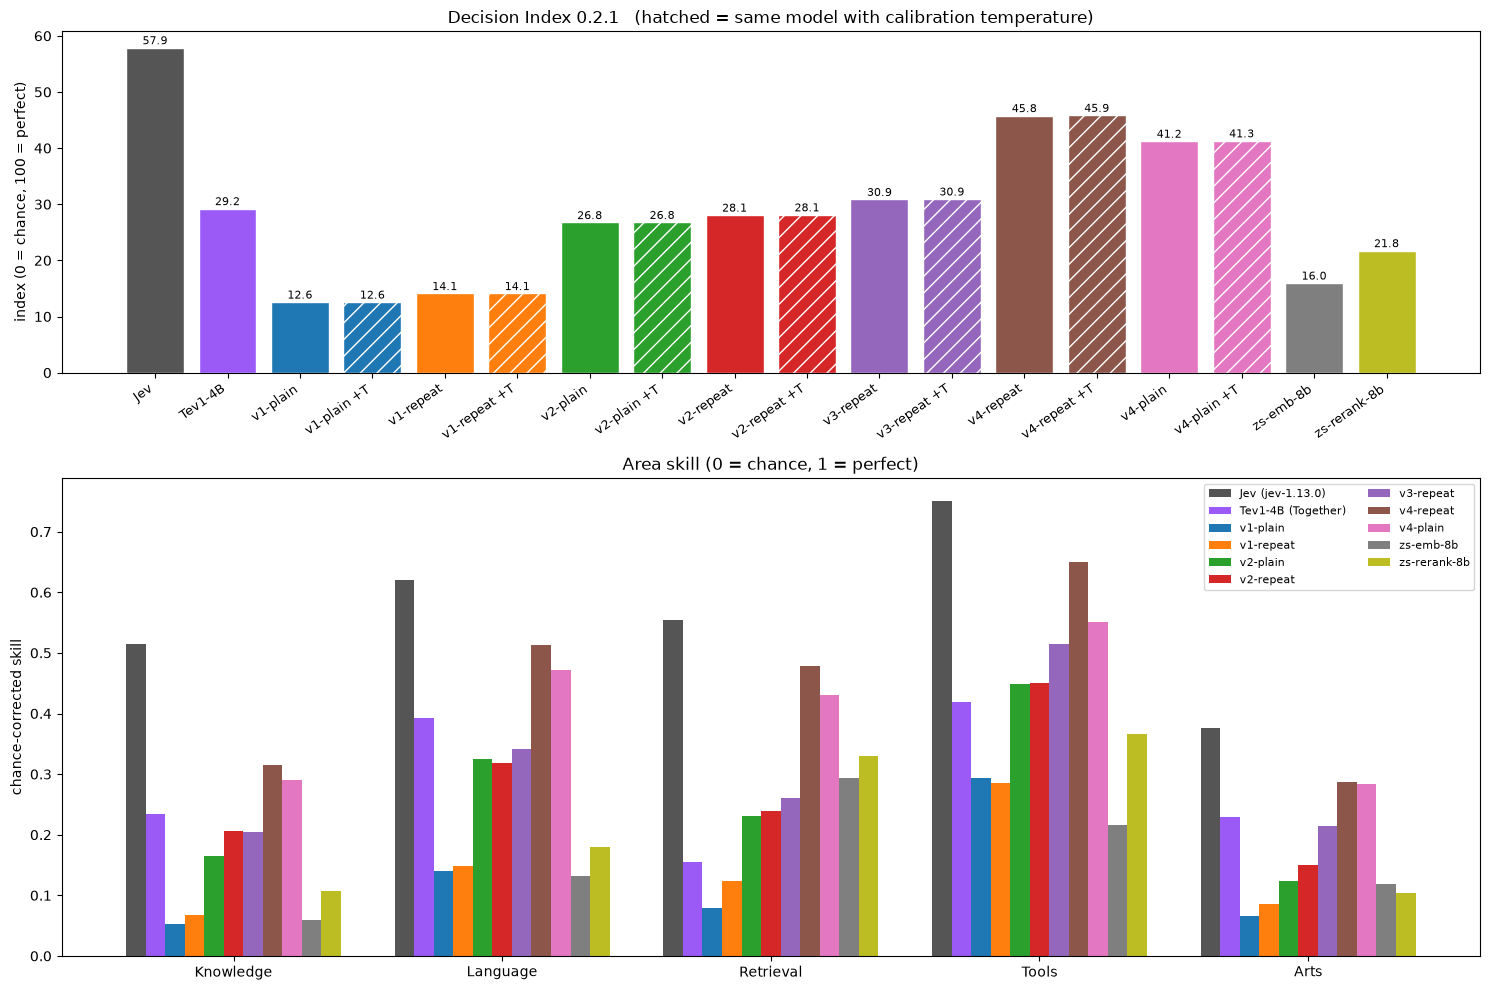

In [14]:
BOARD = requests.get("https://huggingface.co/spaces/multimodalart/jev-decision-index/resolve/main/data/index.json", timeout=60).json()
tev = next(x for x in BOARD["models"] if x["engine"] == "tev1-4b")
jev = BOARD["jev"]
AREAS = [a["id"] for a in BOARD["categories"] if a.get("panel")]
NAMES = {str(k): v.get("short") or v.get("dataset") or str(k) for k, v in BOARD["benchmarks"].items()}
area_of = lambda entry: {c["id"]: c["skill"] for c in entry.get("categories") or []}

rows = [{"model": "Jev (jev-1.13.0)", "index": jev["scores"]["balanced_skill"], **area_of(jev)},
        {"model": "Tev1-4B (Together)", "index": tev["scores"]["balanced_skill"], **area_of(tev)}]
for m in READY_MODELS:
    rows.append({"model": m["label"], "index": m["index"]["index"], **{a["id"]: a["skill"] for a in m["index"]["areas"]}})
HEAD = pd.DataFrame(rows).set_index("model")[["index"] + AREAS]
display(HEAD.round(3))
print("index: 0 = random guessing, 100 = perfect. Area columns: 0-1 chance-corrected skill.")

# One colour per model; its +T variant sits right next to it in the same colour, hatched.
base_names = [n for n in HEAD.index if not n.endswith(" +T")]
order = []
for n in base_names:
    order.append(n)
    if n + " +T" in HEAD.index:
        order.append(n + " +T")
H = HEAD.loc[order]
fixed = {"Jev (jev-1.13.0)": "#555555", "Tev1-4B (Together)": "#9b59f6"}
palette = iter(plt.cm.tab10.colors)
base_color = {n: fixed.get(n) or next(palette) for n in base_names}
color = [base_color[n.replace(" +T", "")] for n in H.index]
hatch = ["//" if n.endswith(" +T") else "" for n in H.index]
short = [n.replace(" (jev-1.13.0)", "").replace(" (Together)", "").replace("scion-", "") for n in H.index]

fig, axes = plt.subplots(2, 1, figsize=(15, 10), gridspec_kw={"height_ratios": [1, 1.4]})
bars = axes[0].bar(range(len(H)), H["index"], color=color, edgecolor="white")
for b, h in zip(bars, hatch):
    b.set_hatch(h)
for i, v in enumerate(H["index"]):
    axes[0].text(i, v + 0.6, f"{v:.1f}", ha="center", fontsize=8)
axes[0].set_xticks(range(len(H)))
axes[0].set_xticklabels(short, rotation=35, ha="right", fontsize=9)
axes[0].set_ylabel("index (0 = chance, 100 = perfect)")
axes[0].set_title(f"Decision Index {EDITION}   (hatched = same model with calibration temperature)")

# Area chart: base models only (+T barely moves area skill), one consistent colour each.
A = HEAD.loc[base_names]
w = 0.8 / len(A)
for k, (name, r) in enumerate(A.iterrows()):
    axes[1].bar(np.arange(len(AREAS)) + (k - (len(A) - 1) / 2) * w, [r[a] for a in AREAS], w,
                label=name.replace("scion-", ""), color=base_color[name])
axes[1].set_xticks(np.arange(len(AREAS)))
axes[1].set_xticklabels([a.title() for a in AREAS])
axes[1].set_ylabel("chance-corrected skill")
axes[1].set_title("Area skill (0 = chance, 1 = perfect)")
axes[1].legend(fontsize=8, ncol=2, loc="upper right")
plt.tight_layout()
plt.savefig(RUNS / "matrix_index.png", dpi=150)
plt.show()

In [15]:
per = []
for bid in sorted({b for m in READY_MODELS for b, v in m["index"]["benchmarks"].items() if v.get("in_index")}, key=int):
    row = {"benchmark": NAMES.get(bid, bid), "jev": jev["results"].get(bid, {}).get("score"),
           "tev": tev["results"].get(bid, {}).get("score")}
    for m in READY_MODELS:
        b = m["index"]["benchmarks"][bid]
        row[m["label"]] = b["raw"]
        row[m["label"] + " cov"] = b["coverage"]
    per.append(row)
PER = pd.DataFrame(per).set_index("benchmark")
display(PER.round(3))
print("Scion: coverage-adjusted native metric (unanswered or contaminated = wrong) and coverage. Jev/Tev: the "
      "board's native metric. Compare directly where our coverage is near 1.0.")

,jev,tev,scion-v1-plain,scion-v1-plain cov,scion-v1-repeat,scion-v1-repeat cov,scion-v2-plain,scion-v2-plain cov,scion-v2-repeat,scion-v2-repeat cov,...,scion-v2-plain +T,scion-v2-plain +T cov,scion-v2-repeat +T,scion-v2-repeat +T cov,scion-v3-repeat +T,scion-v3-repeat +T cov,scion-v4-repeat +T,scion-v4-repeat +T cov,scion-v4-plain +T,scion-v4-plain +T cov
benchmark,,,,,,,,,,,,,,,,,,,,,
BFCL,0.958,0.902,0.724,1.000,0.668,0.999,0.885,1.000,0.900,1.000,...,0.885,1.000,0.900,1.000,0.948,1.000,0.958,1.000,0.937,1.000
ToolRet,0.653,0.650,0.534,1.000,0.566,0.998,0.620,1.000,0.629,0.998,...,0.619,1.000,0.629,0.998,0.629,0.998,0.646,1.000,0.648,1.000
API-Bank,0.882,NaN,0.197,1.000,0.220,1.000,0.514,1.000,0.409,1.000,...,0.514,1.000,0.409,1.000,0.409,1.000,0.809,1.000,0.738,1.000
BANKING77,0.797,NaN,0.161,0.997,0.216,0.997,0.392,0.997,0.402,0.997,...,0.392,0.997,0.402,0.997,0.288,1.000,0.778,1.000,0.753,1.000
CLINC150,0.893,NaN,0.056,1.000,0.106,1.000,0.338,0.999,0.333,1.000,...,0.338,0.999,0.333,1.000,0.413,1.000,0.817,1.000,0.763,1.000
Home appliances,0.523,0.148,0.000,1.000,0.000,1.000,0.023,1.000,0.080,1.000,...,0.023,1.000,0.080,1.000,0.182,1.000,0.386,1.000,0.182,1.000
ContractNLI,0.717,0.677,0.484,1.000,0.495,1.000,0.634,1.000,0.558,1.000,...,0.634,1.000,0.558,1.000,0.498,1.000,0.754,1.000,0.744,1.000
ANLI,0.748,0.564,0.360,1.000,0.354,1.000,0.498,1.000,0.446,1.000,...,0.498,1.000,0.446,1.000,0.526,1.000,0.679,1.000,0.633,1.000
BPoMP,0.906,0.766,0.555,1.000,0.565,1.000,0.588,1.000,0.637,1.000,...,0.588,1.000,0.637,1.000,0.836,1.000,0.934,1.000,0.865,1.000


Scion: coverage-adjusted native metric (unanswered or contaminated = wrong) and coverage. Jev/Tev: the board's native metric. Compare directly where our coverage is near 1.0.


### Calibration

Same 10 bins as the board. Jev's and Tev's curves come from the board (its 28-benchmark subset);
Scion's numbers use every scored choice question, so treat that comparison as indicative. Between our four
models the comparison is exact: same questions, same rule.

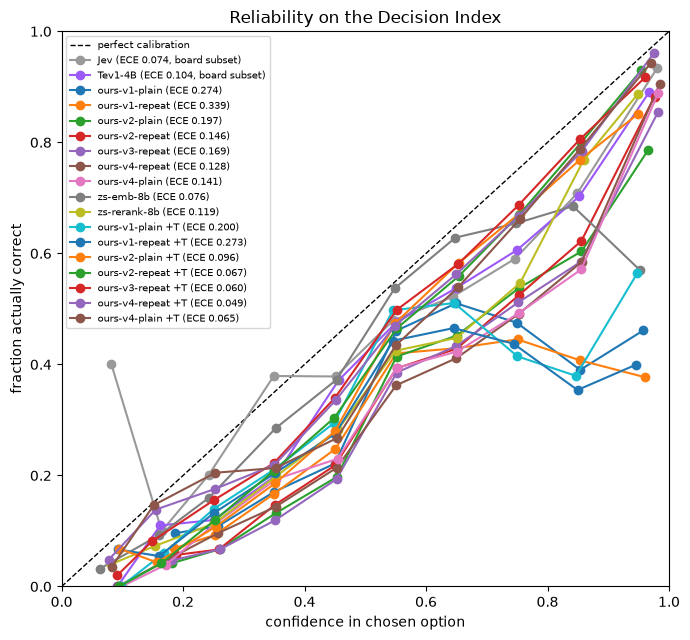

,accuracy,mean_confidence,ece,n
model,,,,
scion-v1-plain,0.417,0.691,0.274,280247
scion-v1-repeat,0.375,0.714,0.339,281444
scion-v2-plain,0.604,0.801,0.197,273757
scion-v2-repeat,0.683,0.829,0.146,280531
scion-v3-repeat,0.672,0.841,0.169,281392
scion-v4-repeat,0.747,0.875,0.128,281466
scion-v4-plain,0.729,0.871,0.141,281454
zs-emb-8b,0.518,0.594,0.076,281476
zs-rerank-8b,0.617,0.736,0.119,281476


Mean confidence above accuracy = overconfident. Top-5 mode makes the chosen option's confidence exact, so these curves are not affected by the tail estimate.


In [10]:
edges = np.linspace(0, 1, 11)
fig, ax = plt.subplots(figsize=(7, 6.5))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
for label, cal, color in (("Jev", jev.get("calibration"), "#999"), ("Tev1-4B", tev.get("calibration"), "#9b59f6")):
    if cal and cal.get("rel"):
        ax.plot([x["conf"] for x in cal["rel"] if x["w"]], [x["acc"] for x in cal["rel"] if x["w"]], "-o", color=color,
                label=f"{label} (ECE {cal['ece']:.3f}, board subset)")
cal_rows = []
for m, color in zip(READY_MODELS, colors[2:]):
    conf, corr = [], []
    for rid, r in m["results"].items():
        if r["status"] != "ok":
            continue
        expected = META[rid][2]
        if not isinstance(expected, dict):
            continue
        for qk, a in r["response"]["answers"].items():
            gold = expected.get(qk)
            if a["type"] == "choice" and gold is not None and not isinstance(gold, (list, dict)):
                conf.append(max(a["probabilities"].values())); corr.append(int(a["choice"] == gold))
    conf, corr = np.array(conf), np.array(corr)
    idx = np.clip(np.digitize(conf, edges[1:-1]), 0, 9)
    rel = [(conf[idx == b].mean(), corr[idx == b].mean(), (idx == b).mean()) for b in range(10) if (idx == b).any()]
    e = sum(abs(a - c) * w for c, a, w in rel)
    cal_rows.append({"model": m["label"], "accuracy": corr.mean(), "mean_confidence": conf.mean(), "ece": e, "n": len(conf)})
    ax.plot([c for c, _, _ in rel], [a for _, a, _ in rel], "-o", color=color, label=f"{m['label']} (ECE {e:.3f})")
ax.set_xlabel("confidence in chosen option"); ax.set_ylabel("fraction actually correct")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(fontsize=7); ax.set_title("Reliability on the Decision Index")
plt.tight_layout(); plt.savefig(RUNS / "matrix_reliability.png", dpi=150); plt.show()
display(pd.DataFrame(cal_rows).set_index("model").round(3))
print("Mean confidence above accuracy = overconfident. Top-5 mode makes the chosen option's confidence exact, "
      "so these curves are not affected by the tail estimate.")

### Calibration the board's way (like-for-like with Jev and Tev)

The board's published recipe (`calibration_note` in its data): benchmarks with a right-or-wrong answer per
question, **excluding ToolRet, BRIGHT, RouterBench and ForecastBench**; **each benchmark weighted equally**;
a **1-in-6 sample of requests**; confidence = probability on the chosen option; 10 bins; rows the entrant
trained on count as wrong. We apply the same rules to Scion. The board does not say how it draws its 1-in-6
sample, so Scion uses a fixed hash of the request id: same size and rule, not the identical rows, which
moves the numbers by well under a point.

In [11]:
BOARD_CAL_EXCLUDE = {2, 36, 6, 48}          # ToolRet, BRIGHT, RouterBench, ForecastBench


def board_style_calibration(m, bins=10):
    per_bench = defaultdict(list)                 # catalog_id -> [(confidence, correct)]
    contaminated = CONTAMINATED.get(m.get("train"), set())
    for rid, (cat, ds, expected, _, qs) in META.items():
        if cat in BOARD_CAL_EXCLUDE or not isinstance(expected, dict):
            continue
        if int(hashlib.sha256(rid.encode()).hexdigest(), 16) % 6:
            continue
        r = m["results"].get(rid)
        answers = (r.get("response") or {}).get("answers", {}) if r and r["status"] == "ok" else {}
        for qk, gold in expected.items():
            if gold is None or isinstance(gold, (list, dict)) or qs[qk]["type"] != "choice":
                continue
            a = answers.get(qk)
            if a is None:              # unanswered: no confidence to calibrate (the board drops these too)
                continue
            right = 0 if rid in contaminated else int(a["choice"] == gold)
            per_bench[cat].append((max(a["probabilities"].values()), right))
    conf, corr, w = [], [], []
    for cat, pts in per_bench.items():             # equal weight per benchmark
        for c, k in pts:
            conf.append(c); corr.append(k); w.append(1.0 / len(pts))
    conf, corr, w = np.array(conf), np.array(corr), np.array(w) / sum(w)
    idx = np.clip(np.digitize(conf, np.linspace(0, 1, bins + 1)[1:-1]), 0, bins - 1)
    e = sum(abs(np.average(corr[idx == b], weights=w[idx == b]) - np.average(conf[idx == b], weights=w[idx == b]))
            * w[idx == b].sum() for b in range(bins) if (idx == b).any())
    return {"accuracy": float(np.average(corr, weights=w)), "mean_confidence": float(np.average(conf, weights=w)),
            "ece": float(e), "n": int(len(conf)), "benchmarks": len(per_bench)}


rows = [{"model": "Jev (board)", **{k: jev["calibration"][k] for k in ("acc", "conf", "ece", "n", "benchmarks")}},
        {"model": "Tev1-4B (board)", **{k: tev["calibration"][k] for k in ("acc", "conf", "ece", "n", "benchmarks")}}]
rows = [{"model": r["model"], "accuracy": r["acc"], "mean_confidence": r["conf"], "ece": r["ece"], "n": r["n"],
         "benchmarks": r["benchmarks"]} for r in rows]
for m in READY_MODELS:
    rows.append({"model": m["label"], **board_style_calibration(m)})
BOARD_CAL = pd.DataFrame(rows).set_index("model")
display(BOARD_CAL.round(3))
print("Same recipe as the board for every row. Tev covers 28 benchmarks because it cannot answer the >24-option "
      "ones; the board drops those for Tev rather than counting them, so its accuracy here is on an easier mix.")

,accuracy,mean_confidence,ece,n,benchmarks
model,,,,,
Jev (board),0.739,0.812,0.074,72594,32
Tev1-4B (board),0.634,0.739,0.104,32652,28
scion-v1-plain,0.416,0.697,0.281,41684,39
scion-v1-repeat,0.439,0.680,0.240,41824,39
scion-v2-plain,0.550,0.786,0.236,40497,39
scion-v2-repeat,0.567,0.774,0.207,41709,39
scion-v3-repeat,0.563,0.817,0.253,41823,39
scion-v4-repeat,0.667,0.843,0.176,41822,39
scion-v4-plain,0.643,0.832,0.189,41818,39


Same recipe as the board for every row. Tev covers 28 benchmarks because it cannot answer the >24-option ones; the board drops those for Tev rather than counting them, so its accuracy here is on an easier mix.


### Head to head with Tev on Tev's own question set

Tev can only answer questions with 2 to 24 options, and the board drops what it cannot answer instead of
counting it. For a like-for-like comparison we restrict Scion to exactly that: the benchmarks Tev answered
and, within them, questions with at most 24 options. Same board recipe otherwise (equal benchmark weights,
1-in-6 sample, 10 bins). Below it, benchmark by benchmark: our accuracy-type score vs Tev's on the
benchmarks both answered in full.

,accuracy,mean_confidence,ece,n,benchmarks
model,,,,,
Tev1-4B (board),0.634,0.739,0.104,32652,28
scion-v2-plain,0.586,0.802,0.216,37950,34
scion-v2-repeat,0.612,0.801,0.189,39162,34
scion-v3-repeat,0.600,0.842,0.242,39275,34
scion-v4-repeat,0.686,0.857,0.171,39274,34
scion-v4-plain,0.666,0.848,0.182,39270,34
zs-emb-8b,0.470,0.634,0.164,39279,34
zs-rerank-8b,0.510,0.692,0.183,39279,34
scion-v2-plain +T,0.586,0.712,0.126,37950,34


Scion restricted to the 35 benchmarks Tev answered and questions with <= 24 options. The board lists 28 for Tev without naming them, so a few of Scion's benchmarks may still be outside its set.


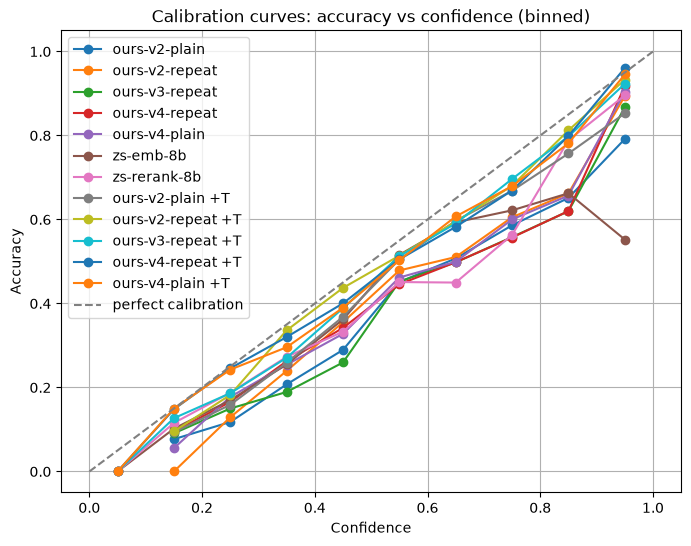

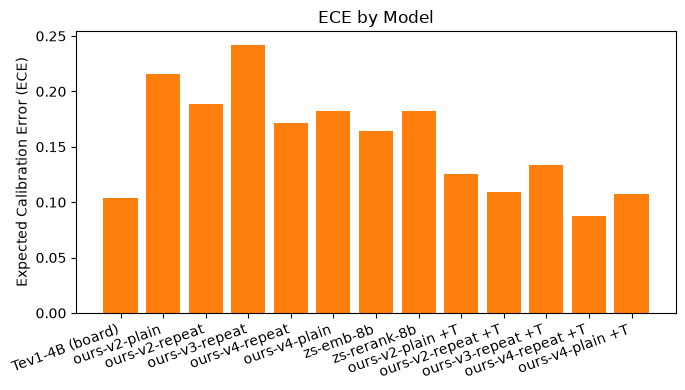

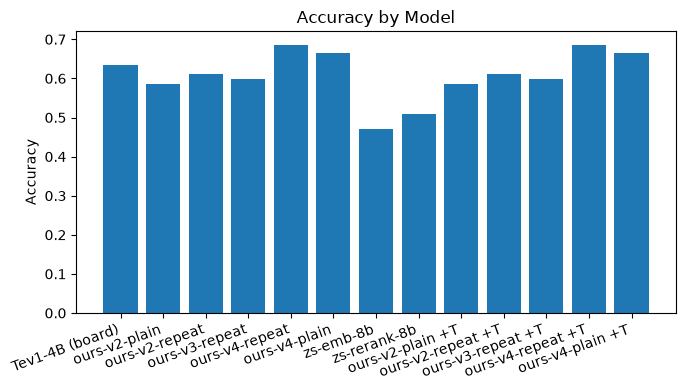

head-to-head model: scion-v4-repeat +T


,metric,Scion,tev,scion_minus_tev,winner
benchmark,,,,,
SGD,macro-F1,0.299,0.407,-0.108,Tev
Habermas,accuracy,0.356,0.416,-0.060,Tev
When2Call,accuracy,0.579,0.605,-0.026,Tev
MuSR,accuracy,0.580,0.580,0.000,tie
ARC-Easy,accuracy,0.987,0.976,0.011,Scion
FinEntity,macro-F1,0.878,0.863,0.015,Scion
PhishNChips,accuracy,0.527,0.506,0.021,Scion
Humicroedit,accuracy,0.610,0.583,0.027,Scion
ARC-Challenge,accuracy,0.950,0.922,0.028,Scion


{'Tev': 3, 'tie': 1, 'Scion': 29} (within 0.01 counted as a tie; per-benchmark margins, not paired tests)


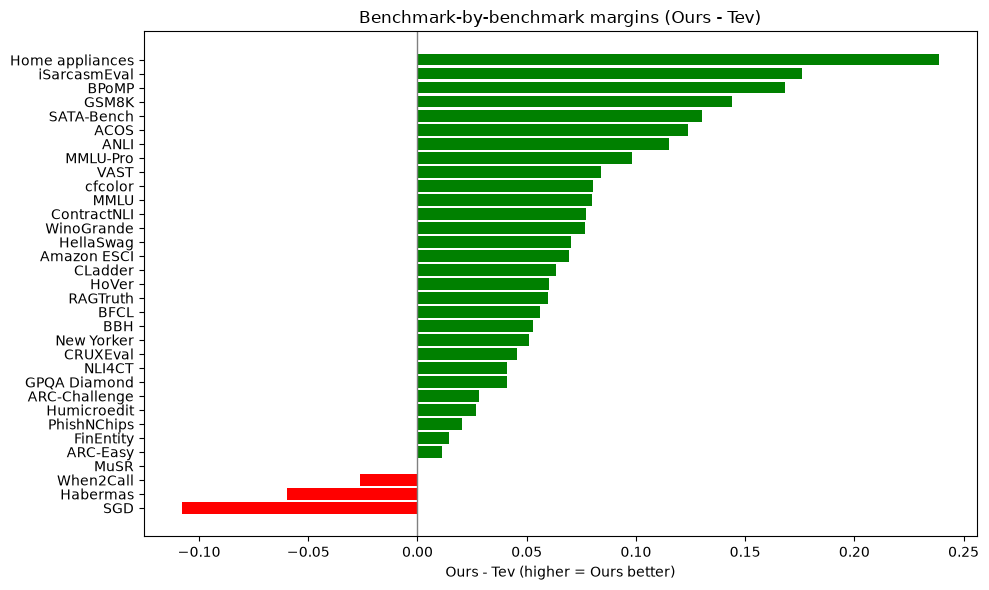

In [16]:
import matplotlib.pyplot as plt

TEV_ANSWERED = {int(k) for k, v in tev["results"].items() if v.get("answered", 0) > 0} - BOARD_CAL_EXCLUDE
TEV_MAX_OPTIONS = 24


def tev_style_calibration(m, bins=10, for_plot=False):
    per_bench = defaultdict(list)
    contaminated = CONTAMINATED.get(m.get("train"), set())
    raw_points = []
    for rid, (cat, ds, expected, _, qs) in META.items():
        if cat not in TEV_ANSWERED or not isinstance(expected, dict):
            continue
        if int(hashlib.sha256(rid.encode()).hexdigest(), 16) % 6:
            continue
        if any(q["type"] == "choice" and len(q["criteria"]) > TEV_MAX_OPTIONS for q in qs.values()):
            continue
        r = m["results"].get(rid)
        answers = (r.get("response") or {}).get("answers", {}) if r and r["status"] == "ok" else {}
        for qk, gold in expected.items():
            if gold is None or isinstance(gold, (list, dict)) or qs[qk]["type"] != "choice":
                continue
            a = answers.get(qk)
            if a is None:
                continue
            prob = max(a["probabilities"].values())
            correct = 0 if rid in contaminated else int(a["choice"] == gold)
            per_bench[cat].append((prob, correct))
            if for_plot:
                raw_points.append((prob, correct))
    conf, corr, w = [], [], []
    for pts in per_bench.values():
        for c, k in pts:
            conf.append(c); corr.append(k); w.append(1.0 / len(pts))
    conf, corr, w = np.array(conf), np.array(corr), np.array(w) / sum(w)
    idx = np.clip(np.digitize(conf, np.linspace(0, 1, bins + 1)[1:-1]), 0, bins - 1)
    e = sum(abs(np.average(corr[idx == b], weights=w[idx == b]) - np.average(conf[idx == b], weights=w[idx == b]))
            * w[idx == b].sum() for b in range(bins) if (idx == b).any())
    res = {
        "accuracy": float(np.average(corr, weights=w)),
        "mean_confidence": float(np.average(conf, weights=w)),
        "ece": float(e),
        "n": int(len(conf)),
        "benchmarks": len(per_bench)
    }
    if for_plot:
        res["conf"] = conf
        res["corr"] = corr
        res["idx"] = idx
        res["raw_points"] = raw_points
    return res

# Build the main table
rows = [{
    "model": "Tev1-4B (board)",
    "accuracy": tev["calibration"]["acc"],
    "mean_confidence": tev["calibration"]["conf"],
    "ece": tev["calibration"]["ece"],
    "n": tev["calibration"]["n"],
    "benchmarks": tev["calibration"]["benchmarks"],
}]
to_graph = []
for m in READY_MODELS:
    if any(v in m["label"] for v in ("v2", "v3", "v4", "zs-")):
        row = tev_style_calibration(m)
        rows.append({"model": m["label"], **row})
        to_graph.append((m["label"], tev_style_calibration(m, bins=10, for_plot=True)))

display(pd.DataFrame(rows).set_index("model").round(3))
print(f"Scion restricted to the {len(TEV_ANSWERED)} benchmarks Tev answered and questions with <= {TEV_MAX_OPTIONS} options. "
      "The board lists 28 for Tev without naming them, so a few of Scion's benchmarks may still be outside its set.")

# --- Calibration curves graph ---
plt.figure(figsize=(8, 6))
for label, out in to_graph:
    conf = out["conf"]
    corr = out["corr"]
    idx = out["idx"]
    bins = 10
    bin_edges = np.linspace(0, 1, bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    accs = []
    confs = []
    for b in range(bins):
        mask = idx == b
        if not np.any(mask):
            accs.append(np.nan)
            confs.append(np.nan)
            continue
        accs.append(np.average(corr[mask]))
        confs.append(np.average(conf[mask]))
    plt.plot(bin_centers, accs, marker='o', label=f"{label}")
plt.plot([0, 1], [0, 1], "--", color="grey", label="perfect calibration")
plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title("Calibration curves: accuracy vs confidence (binned)")
plt.legend()
plt.grid(True)
plt.show()

# --- ECE bar graph ---
plt.figure(figsize=(7, 4))
models = [r["model"] for r in rows]
ece_vals = [r["ece"] for r in rows]
plt.bar(models, ece_vals, color="C1")
plt.ylabel("Expected Calibration Error (ECE)")
plt.title("ECE by Model")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# --- Accuracy bar graph ---
plt.figure(figsize=(7, 4))
acc_vals = [r["accuracy"] for r in rows]
plt.bar(models, acc_vals, color="C0")
plt.ylabel("Accuracy")
plt.title("Accuracy by Model")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Per-benchmark head-to-head dataframe and chart
_pref = ["scion-v4-repeat +T", "scion-v3-repeat +T", "scion-v2-repeat +T"]
best = next(m for lab in _pref for m in READY_MODELS if m["label"] == lab)
print("head-to-head model:", best["label"])
h2h = []
for bid in sorted(TEV_ANSWERED):
    t = tev["results"].get(str(bid), {})
    ob = best["index"]["benchmarks"].get(str(bid))
    if not ob or t.get("answered") != t.get("requests") or t.get("score") is None or ob["coverage"] < 0.99:
        continue
    lower_better = bid == 48
    diff = (t["score"] - ob["raw"]) if lower_better else (ob["raw"] - t["score"])
    h2h.append({"benchmark": NAMES.get(str(bid), bid), "metric": t.get("metric"), "Scion": ob["raw"],
                "tev": t["score"], "scion_minus_tev": diff, "winner": "Scion" if diff > 0.01 else "Tev" if diff < -0.01 else "tie"})
H2H = pd.DataFrame(h2h).set_index("benchmark").sort_values("scion_minus_tev")
display(H2H.round(3))
print(dict(Counter(H2H.winner)), "(within 0.01 counted as a tie; per-benchmark margins, not paired tests)")

# --- Per-benchmark scion-vs-Tev bar graph ---
plt.figure(figsize=(10, 6))
h2h_df = H2H.reset_index()
plt.barh(h2h_df["benchmark"], h2h_df["scion_minus_tev"], color=np.where(h2h_df["scion_minus_tev"] > 0, "green", "red"))
plt.xlabel("Scion - Tev (higher = Scion better)")
plt.title("Benchmark-by-benchmark margins (Scion - Tev)")
plt.axvline(0, color="grey", lw=1)
plt.tight_layout()
plt.show()

## 7. Tear down

In [13]:
for d in DEPLOYMENTS.values():
    try:
        client.deployments.update(d["id"], base_model=d["base"], min_replica_count=0, max_replica_count=1)
        client.deployments.scale(d["id"], replica_count=0)
        print("scaled to 0:", d["id"])
    except Exception as e:  # noqa: BLE001
        print(f"{d['id']}: {str(e)[:120]}")

scaled to 0: jev-di-0p6b
scaled to 0: jev-di-4b
scaled to 0: jev-di-9b
